In [1]:
import pandas as pd

df = pd.read_csv("FC26.csv", low_memory=False)

print(df.shape)
print(df.columns[:20])
print(df.info())

(18405, 110)
Index(['player_id', 'player_url', 'fifa_version', 'fifa_update',
       'fifa_update_date', 'short_name', 'long_name', 'player_positions',
       'overall', 'potential', 'value_eur', 'wage_eur', 'age', 'dob',
       'height_cm', 'weight_kg', 'league_id', 'league_name', 'league_level',
       'club_team_id'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18405 entries, 0 to 18404
Columns: 110 entries, player_id to player_face_url
dtypes: float64(16), int64(48), object(46)
memory usage: 15.4+ MB
None


In [2]:
cols = [
    'short_name', 'age', 'player_positions',
    'overall', 'potential',
    'pace', 'shooting', 'passing',
    'dribbling', 'defending', 'physic'
]

df = df[cols].dropna()

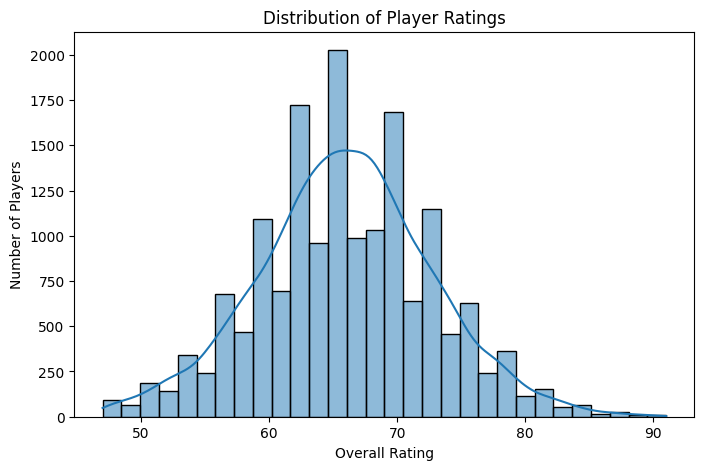

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(df['overall'], bins=30, kde=True)

plt.title("Distribution of Player Ratings")
plt.xlabel("Overall Rating")
plt.ylabel("Number of Players")

plt.show()

This first plot examines how player overall ratings are distributed across the dataset.

- Check for skewness in the distribution
- Identify whether elite players are rare
- Look for gaps or clusters in player quality

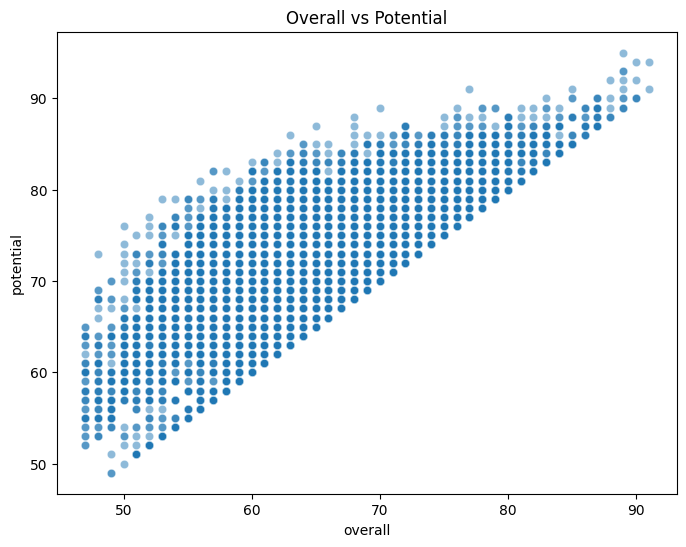

In [4]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='overall', y='potential', alpha=0.5)

plt.title("Overall vs Potential")
plt.show()

This scatter plot compares current overall rating to potential rating.

- Players above the diagonal may still improve
- Players near the diagonal are close to peak form
- Players below the line may be underperforming relative to potential

In [5]:
df['potential_gap'] = df['potential'] - df['overall']

This section identifies players who are undervalued based on the difference between potential and current rating.

- Compare current performance to future upside
- Find players with high improvement potential
- Highlight scouting targets for development

In [6]:
print(df.sort_values(by='potential_gap', ascending=False).head(10)[
    ['short_name', 'overall', 'potential', 'potential_gap']
])

         short_name  overall  potential  potential_gap
16474  G. Caraballo       50         76             26
16420      A. Kalın       53         79             26
14532      I. Tyjon       57         82             25
16485      C. Cupps       52         77             25
15084       A. Tatu       57         82             25
15189       L. Wong       56         81             25
16680      A. Saidi       48         73             25
14402  M. Mikkelsen       54         79             25
14179    A. Ouahabi       55         79             24
13198   Y. Hamdaoui       55         79             24


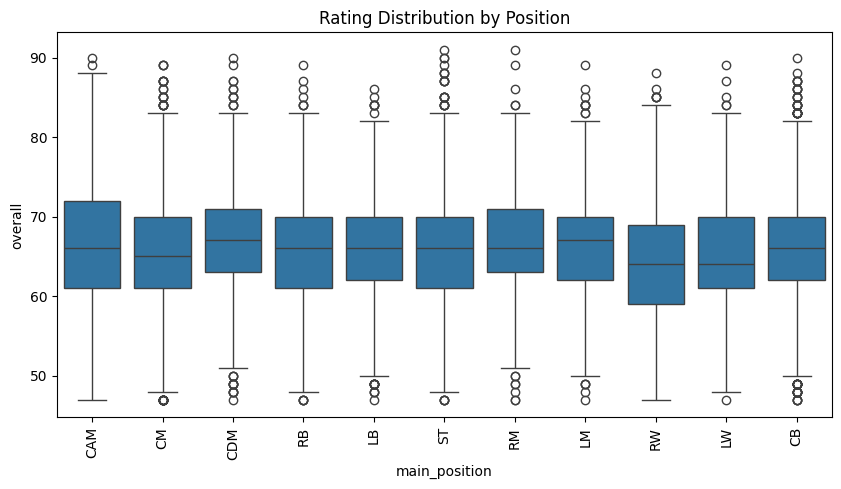

In [7]:
df['main_position'] = df['player_positions'].apply(lambda x: x.split(',')[0])

plt.figure(figsize=(10,5))
sns.boxplot(data=df, x='main_position', y='overall')

plt.xticks(rotation=90)
plt.title("Rating Distribution by Position")

plt.show()

This plot explores how overall rating varies by player position.

- Which positions contain the strongest players?
- Which positions show the most variability?
- Where do strengths and weaknesses cluster?

This section explores relationships between the main player attributes through correlation and pairwise plots.

- Look for strong positive or negative relationships
- Identify feature pairs that move together
- Note potential multicollinearity before modeling

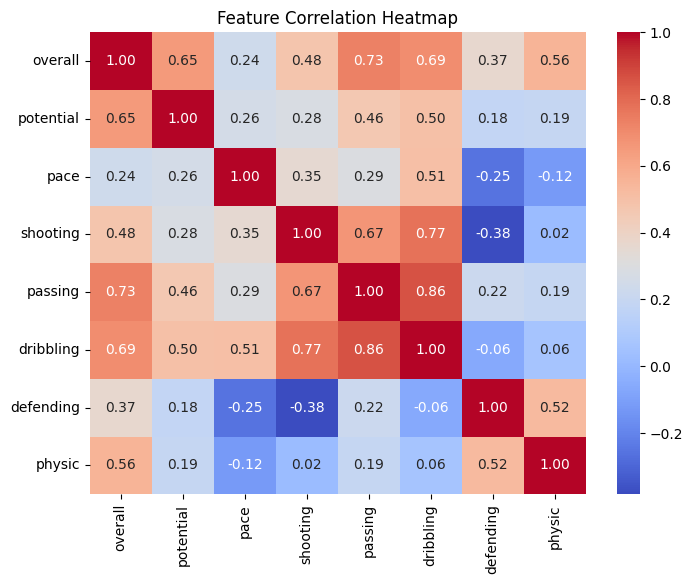

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

num_cols = [
    'overall', 'potential',
    'pace', 'shooting', 'passing',
    'dribbling', 'defending', 'physic'
]

corr = df[num_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")

plt.title("Feature Correlation Heatmap")
plt.show()

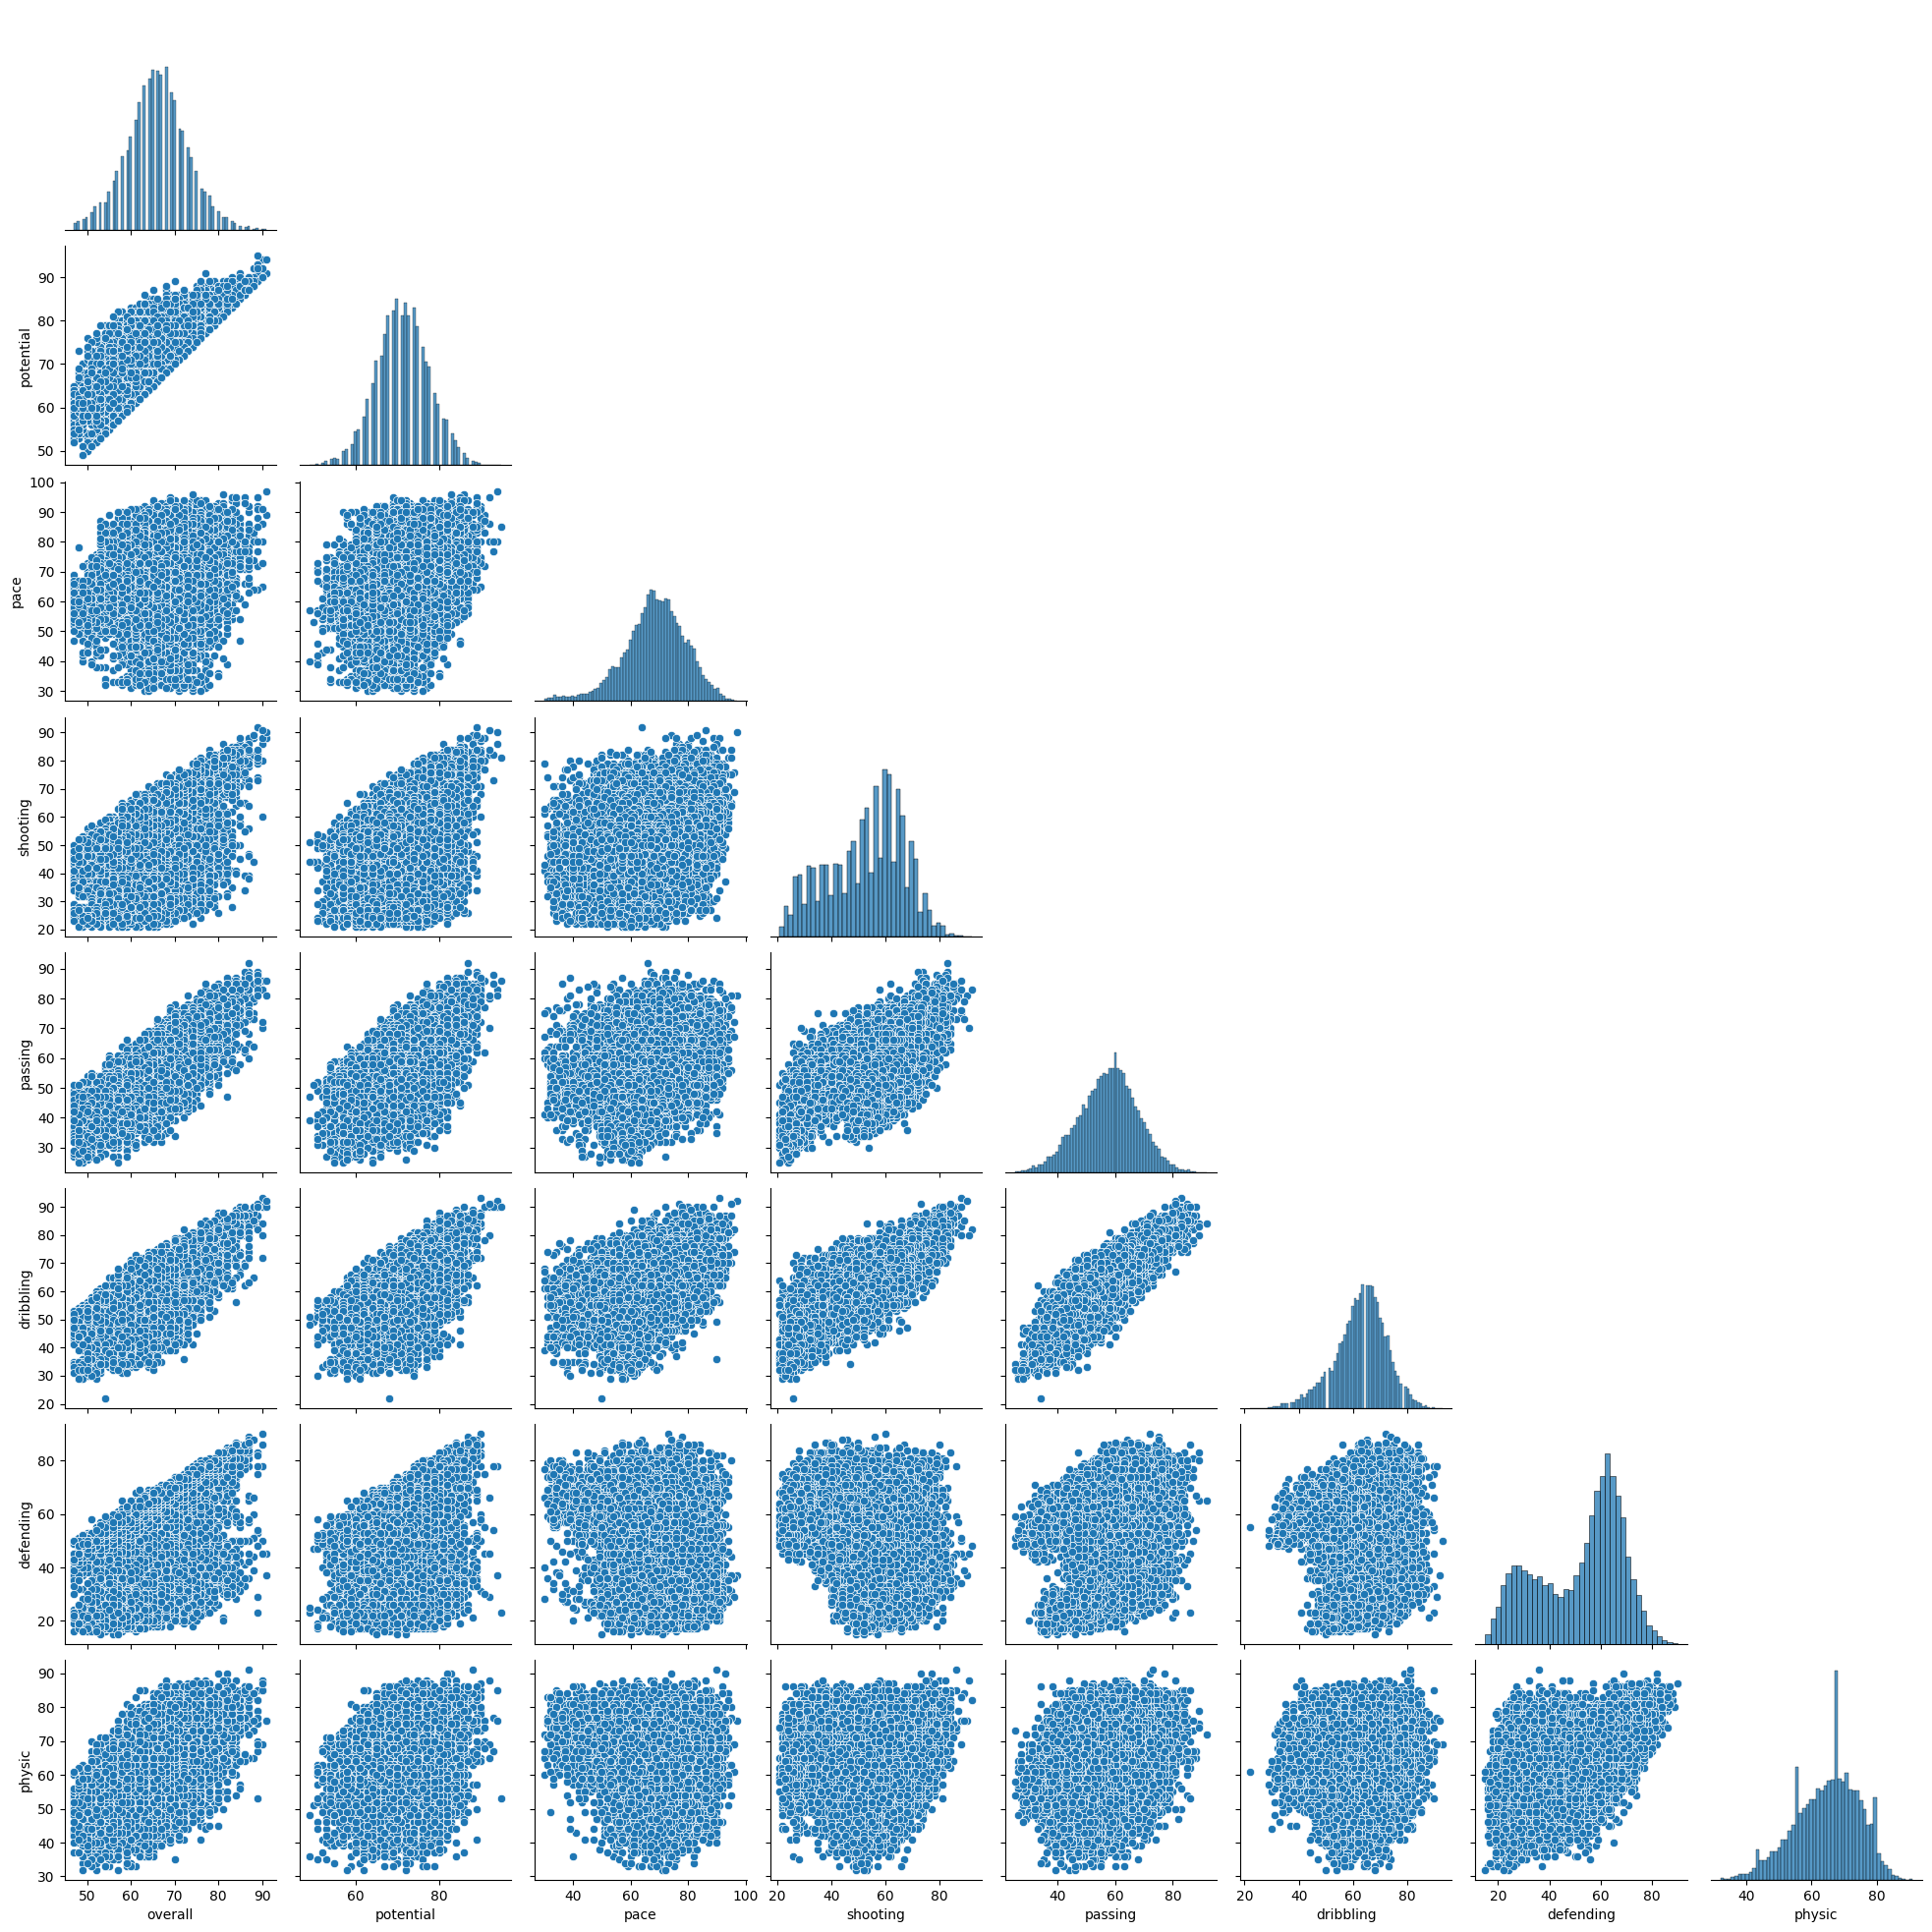

In [9]:
sns.pairplot(df[num_cols], corner=True)
plt.show()

This pairwise visualization helps reveal structure in the player attribute space.

- Observe non-linear relationships
- Detect natural clusters of player types
- Spot outliers that may require special attention

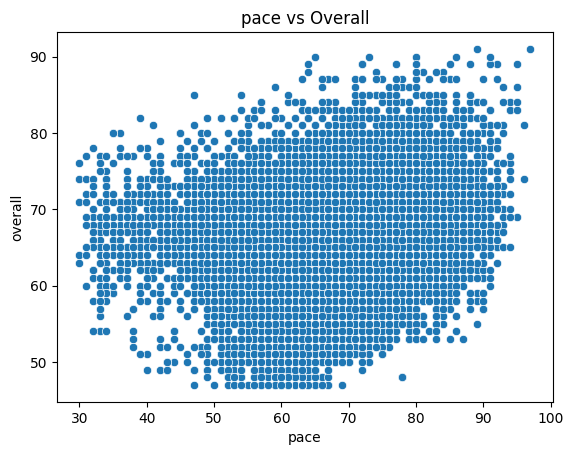

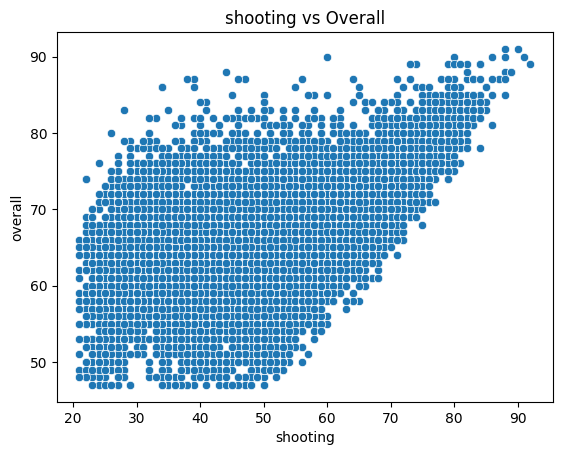

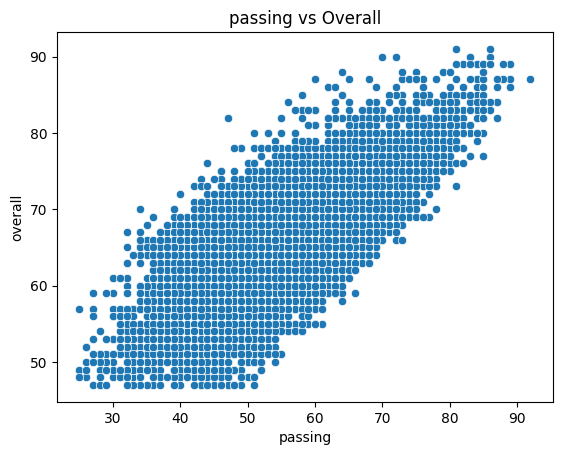

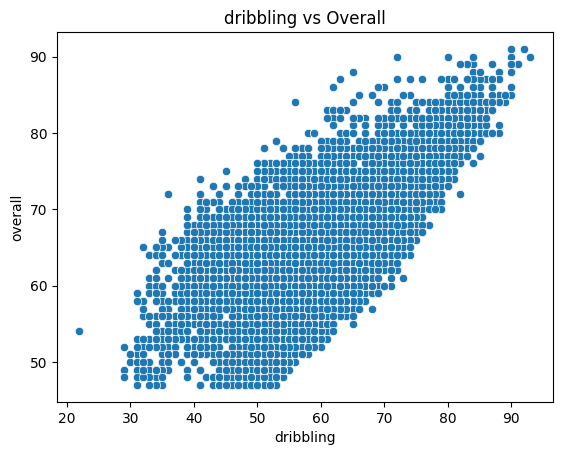

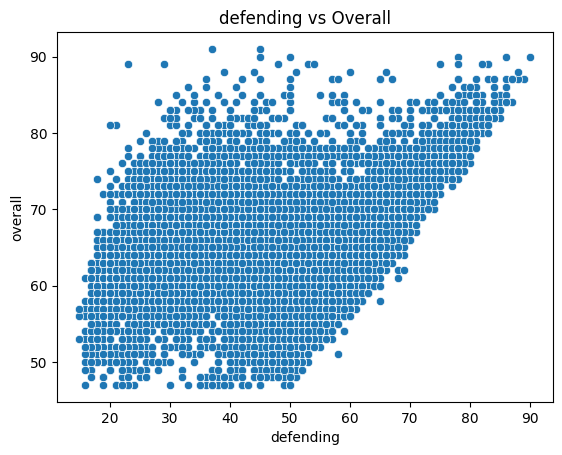

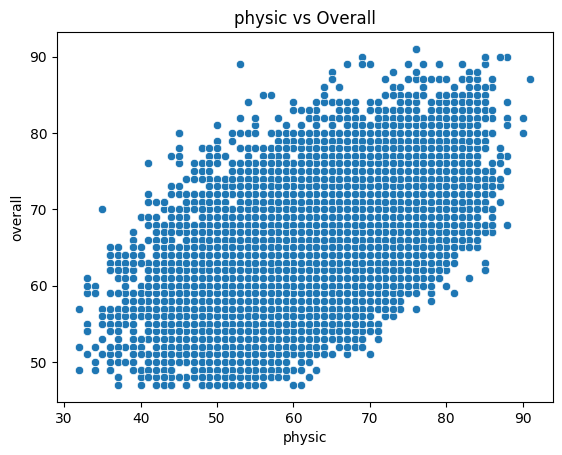

In [10]:
for col in ['pace', 'shooting', 'passing', 'dribbling', 'defending', 'physic']:
    sns.scatterplot(data=df, x=col, y='overall')
    plt.title(f"{col} vs Overall")
    plt.show()

These scatterplots help you recognize role-specific skill patterns.

- Attackers often show strong shooting and dribbling links
- Defenders tend to cluster around defending and physical strength
- Midfielders usually demonstrate higher passing and balance

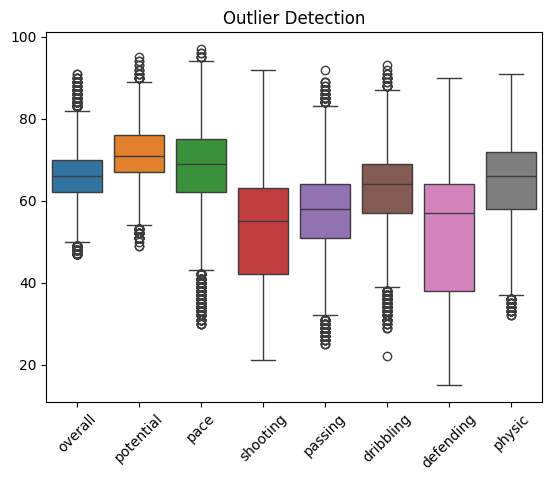

In [11]:
sns.boxplot(data=df[num_cols])
plt.xticks(rotation=45)
plt.title("Outlier Detection")
plt.show()

#### Feature Engineering
This section builds derived metrics to better capture player strengths.

- Create composite scores for attack, playmaking, and defense
- Use engineered features to improve model input
- Make player comparisons more meaningful

In [12]:
df['attacking_score'] = (
    df['shooting'] * 0.4 +
    df['dribbling'] * 0.3 +
    df['pace'] * 0.3
)

df['playmaking_score'] = (
    df['passing'] * 0.5 +
    df['dribbling'] * 0.3 +
    df['pace'] * 0.2
)

df['defensive_score'] = (
    df['defending'] * 0.6 +
    df['physic'] * 0.4
)

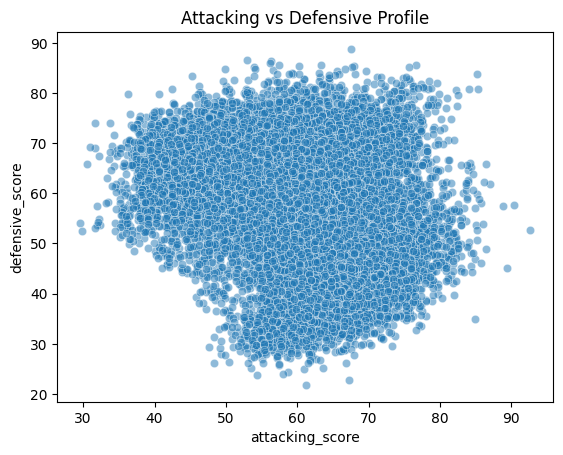

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(
    data=df,
    x='attacking_score',
    y='defensive_score',
    alpha=0.5
)

plt.title("Attacking vs Defensive Profile")
plt.show()

This plot compares attacking and defensive profiles to interpret player roles.

- Top-right indicates balanced, complete players
- Bottom-left indicates lower overall profiles
- High attack and low defense suggests forwards
- High defense and low attack suggests defenders

In [14]:
import numpy as np

df['balance_score'] = df[
    ['pace', 'shooting', 'passing', 'dribbling', 'defending', 'physic']
].std(axis=1)

In [15]:
df['efficiency'] = df['overall'] / (
    df['attacking_score'] +
    df['playmaking_score'] +
    df['defensive_score']
)

In [16]:
def classify_role(row):
    if row['attacking_score'] > row['defensive_score'] and row['attacking_score'] > row['playmaking_score']:
        return 'Attacker'
    elif row['defensive_score'] > row['attacking_score']:
        return 'Defender'
    else:
        return 'Playmaker'

df['role'] = df.apply(classify_role, axis=1)

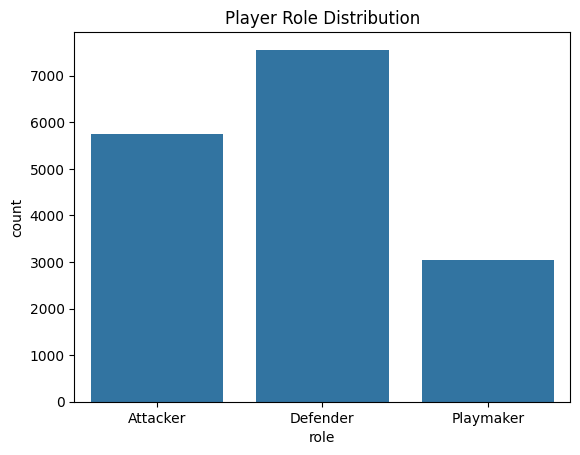

In [17]:
sns.countplot(data=df, x='role')
plt.title("Player Role Distribution")
plt.show()

In [18]:
df['potential_gap'] = df['potential'] - df['overall']

top_gems = df.sort_values(by='potential_gap', ascending=False).head(10)

print(top_gems[['short_name', 'role', 'overall', 'potential', 'potential_gap']])

         short_name       role  overall  potential  potential_gap
16474  G. Caraballo   Attacker       50         76             26
16420      A. Kalın   Attacker       53         79             26
14532      I. Tyjon   Attacker       57         82             25
16485      C. Cupps   Defender       52         77             25
15084       A. Tatu   Attacker       57         82             25
15189       L. Wong  Playmaker       56         81             25
16680      A. Saidi   Attacker       48         73             25
14402  M. Mikkelsen  Playmaker       54         79             25
14179    A. Ouahabi  Playmaker       55         79             24
13198   Y. Hamdaoui  Playmaker       55         79             24


Use this shortlist of high potential-gap players to generate actionable insights.

- Identify underpriced players with strong upside
- Spot playmakers and attackers with hidden growth potential
- Recognize defenders who may improve significantly

#### PCA + Clustering
This section reduces the feature space and groups players into archetypes.

- Use PCA to capture the main variation in skill profiles
- Apply clustering to identify similar player groups
- Visualize player archetypes in a 2D skill map

In [19]:
features = [
    'pace', 'shooting', 'passing',
    'dribbling', 'defending', 'physic',
    'attacking_score', 'playmaking_score', 'defensive_score'
]

X = df[features]

In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [21]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df['pca1'] = X_pca[:, 0]
df['pca2'] = X_pca[:, 1]

This PCA step transforms player features into two key components.

- PC1 represents overall ability and dominance
- PC2 captures a playstyle axis from attack to defense
- This makes skill patterns easier to visualize

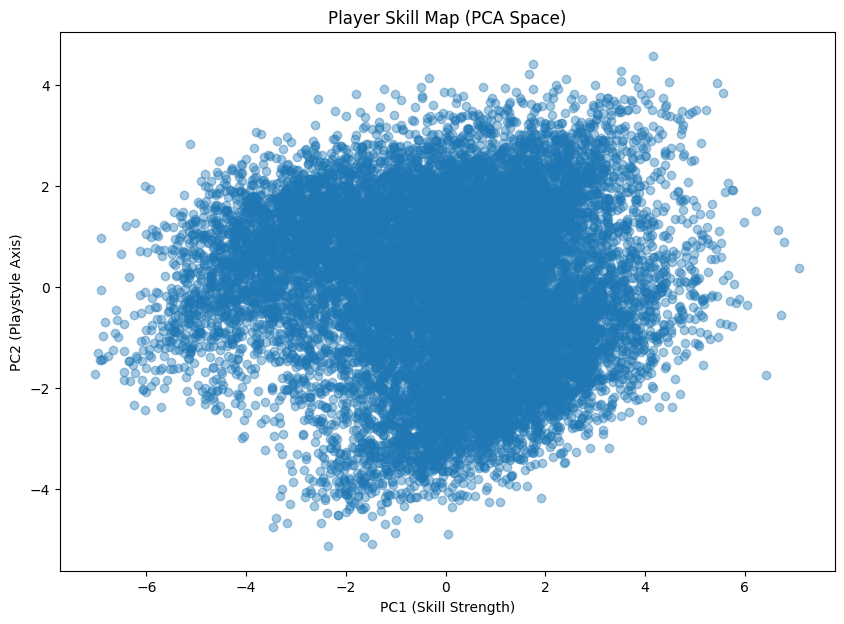

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,7))
plt.scatter(df['pca1'], df['pca2'], alpha=0.4)

plt.title("Player Skill Map (PCA Space)")
plt.xlabel("PC1 (Skill Strength)")
plt.ylabel("PC2 (Playstyle Axis)")

plt.show()

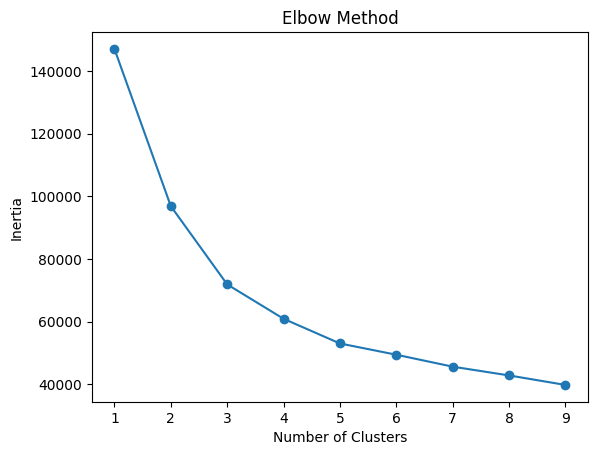

In [23]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(1,10), inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

In [24]:
kmeans = KMeans(n_clusters=5, random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)

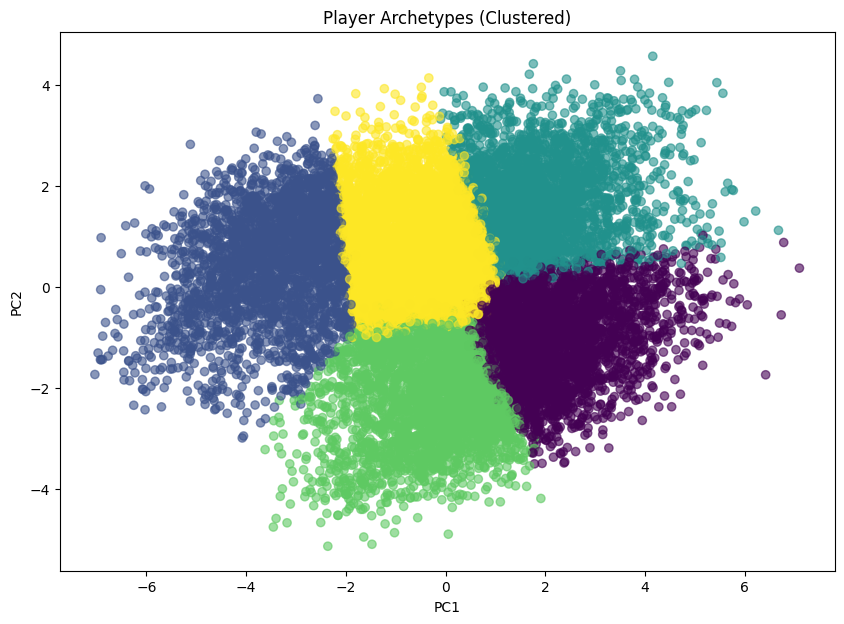

In [25]:
plt.figure(figsize=(10,7))
plt.scatter(
    df['pca1'], df['pca2'],
    c=df['cluster'],
    cmap='viridis',
    alpha=0.6
)

plt.title("Player Archetypes (Clustered)")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.show()

In [26]:
cluster_summary = df.groupby('cluster')[features].mean()
print(cluster_summary)

              pace   shooting    passing  dribbling  defending     physic  \
cluster                                                                     
0        77.025705  66.435737  63.220690  70.905016  36.879310  62.517868   
1        57.802118  32.119022  45.070464  48.652793  61.253742  67.209200   
2        71.536902  62.632979  69.121676  71.870013  65.871011  71.247340   
3        67.921363  55.503277  51.010157  59.902359  31.780799  54.790629   
4        66.817639  47.169959  58.068213  61.831879  61.667203  67.384474   

         attacking_score  playmaking_score  defensive_score  
cluster                                                      
0              70.953511         68.286991        47.134734  
1              44.784082         48.691493        63.635926  
2              68.075266         70.429222        68.021543  
3              60.548427         57.060059        40.984731  
4              57.462839         60.947198        63.954111  


Cluster explanations:

- Cluster 0: High defending and physical strength → Defensive anchors
- Cluster 1: High passing and dribbling → Playmakers
- Cluster 2: High shooting and pace → Strikers
- Cluster 3: Balanced profile → Box-to-box midfielders
- Cluster 4: Pace-heavy traits → Wingers

In [27]:
df['potential_gap'] = df['potential'] - df['overall']
gems = df.sort_values(by='potential_gap', ascending=False)

print(gems[['short_name', 'cluster', 'overall', 'potential']].head(15))

             short_name  cluster  overall  potential
16474      G. Caraballo        3       50         76
16420          A. Kalın        3       53         79
14532          I. Tyjon        3       57         82
16485          C. Cupps        1       52         77
15084           A. Tatu        3       57         82
15189           L. Wong        3       56         81
16680          A. Saidi        3       48         73
14402      M. Mikkelsen        3       54         79
14179        A. Ouahabi        3       55         79
13198       Y. Hamdaoui        3       55         79
14153       P. Villalba        3       58         82
16314  O. Graham-Roache        3       52         76
16640      N. Savonnier        1       50         74
16037           Z. Gozo        3       55         79
16618       J. Necovski        1       51         75


In [28]:
features = [
    'pace', 'shooting', 'passing',
    'dribbling', 'defending', 'physic',
    'attacking_score', 'playmaking_score', 'defensive_score'
]

X = df[features]
y = df['potential']

In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [30]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [31]:
from sklearn.metrics import mean_absolute_error, r2_score

y_pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

MAE: 3.688314469256653
R2: 0.46710186780469354


In [32]:
import pandas as pd

importance = pd.Series(model.feature_importances_, index=features)
print(importance.sort_values(ascending=False))

dribbling           0.333275
defending           0.167467
playmaking_score    0.085675
attacking_score     0.079933
defensive_score     0.076912
pace                0.072851
shooting            0.068250
physic              0.067330
passing             0.048307
dtype: float64


This final similarity section computes player similarity using their skill attributes.

- Use cosine similarity to compare players in feature space
- Enable recommendations for similar players
- Support scouting and player comparison with nearest neighbors

In [33]:
from sklearn.metrics.pairwise import cosine_similarity

similarity = cosine_similarity(X)

In [34]:
def get_similar_players(player_name, top_n=5):
    matches = df[df['short_name'].str.lower() == player_name.lower()]
    
    if matches.empty:
        print(f"❌ Player '{player_name}' not found in dataset")
        return []
    
    idx = matches.index[0]
    
    scores = list(enumerate(similarity[idx]))
    scores = sorted(scores, key=lambda x: x[1], reverse=True)[1:top_n+1]
    
    player_indices = [i[0] for i in scores]
    
    return df['short_name'].iloc[player_indices].tolist()

In [35]:
print(get_similar_players("M. Olise"))

['F. Wirtz', 'N. Mosti', 'H. Ziyech', 'Pep Biel', 'F. Đuričić']


This section trains a baseline XGBoost regression model to predict player potential.

- Use fixed hyperparameters for the initial benchmark
- Fit the model on training data
- Evaluate baseline performance before tuning

In [36]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [37]:
from sklearn.metrics import mean_absolute_error, r2_score

y_pred = xgb.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

MAE: 3.6338467597961426
R2: 0.48213255405426025


In [38]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'n_estimators': [200, 300, 500],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

search = RandomizedSearchCV(
    XGBRegressor(random_state=42),
    param_grid,
    n_iter=10,
    cv=3,
    verbose=1,
    n_jobs=-1
)

search.fit(X_train, y_train)

best_model = search.best_estimator_

Fitting 3 folds for each of 10 candidates, totalling 30 fits


In [39]:
y_pred = best_model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

MAE: 3.6240696907043457
R2: 0.4918364882469177


After tuning the XGBoost hyperparameters, we re-evaluate the best model on the test set.

- Compare MAE and R² to the baseline model
- Assess generalization to unseen data
- View feature importances to understand what drives predictions

In [40]:
import pandas as pd

importance = pd.Series(best_model.feature_importances_, index=X.columns)
print(importance.sort_values(ascending=False))

dribbling           0.469789
defending           0.144927
playmaking_score    0.140732
defensive_score     0.062321
physic              0.040108
attacking_score     0.039254
shooting            0.039243
pace                0.037940
passing             0.025686
dtype: float32
